# PJM LMP Market Forecasting and Analytics

This notebook builds a clean, industry-style energy market analytics pipeline using PJM AEP LMP data, load data, and weather data. The goal is to create a reproducible market forecasting workflow with robust feature engineering, XGBoost forecasting, spike risk modeling, and operational interpretation.

## 1. Data Pipeline

Load, clean, and validate the PJM AEP LMP dataset. Then merge the market data with the cleaned hourly load/weather base dataset to create a master market analytics table.

The PJM datetime field is expressed in Eastern Prevailing Time (EPT). This means the fall-back transition at 2024-11-03 produces two distinct 1 AM records, which is expected and should be retained rather than deduplicated.

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style='whitegrid')
pd.options.display.max_columns = 100
pd.options.display.width = 120

In [78]:
def load_clean_lmp_data(paths):
    lmp_frames = []
    for path in paths:
        df = pd.read_csv(path)
        lmp_frames.append(df)
    market_df = pd.concat(lmp_frames, ignore_index=True)

    market_df = market_df.rename(columns={
        'datetime_beginning_ept': 'datetime',
        'total_lmp_da': 'total_lmp_day_ahead',
        'total_lmp_rt': 'total_lmp_real_time',
        'congestion_price_da': 'congestion_price_day_ahead',
        'congestion_price_rt': 'congestion_price_real_time',
        'marginal_loss_price_da': 'marginal_loss_price_day_ahead',
        'marginal_loss_price_rt': 'marginal_loss_price_real_time'
    })

    market_df['datetime'] = pd.to_datetime(market_df['datetime'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    market_df = market_df.sort_values('datetime').reset_index(drop=True)
    keep_cols = [
        'datetime',
        'total_lmp_day_ahead',
        'total_lmp_real_time',
        'congestion_price_day_ahead',
        'congestion_price_real_time',
        'marginal_loss_price_day_ahead',
        'marginal_loss_price_real_time'
    ]
    market_df = market_df[keep_cols].copy()
    return market_df

def validate_hourly_index(df, datetime_col='datetime'):
    duplicates = df[datetime_col].duplicated().sum()
    expected_index = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='H')
    missing_times = expected_index.difference(df[datetime_col])
    return duplicates, missing_times

In [79]:
lmp_paths = [
    '../data/rt_da_monthly_lmps_2024.csv',
    '../data/rt_da_monthly_lmps_2025.csv'
] 
market_df = load_clean_lmp_data(lmp_paths)

print('LMP rows:', len(market_df))
print('LMP columns:', market_df.columns.tolist())
print('Missing datetime rows:', market_df['datetime'].isna().sum())
duplicates, missing_times = validate_hourly_index(market_df)
print('Duplicate datetimes:', duplicates)
print('Missing timestamp count:', len(missing_times))
if duplicates > 0:
    print('Note: Duplicate 1 AM entries on 2024-11-03 correspond to the DST fall-back transition in EPT. Both entries are expected and retained.')
if len(missing_times) > 0:
    print('Missing ranges sample:', missing_times[:10])
    if pd.Timestamp('2024-03-10 02:00:00') in missing_times or pd.Timestamp('2025-03-09 02:00:00') in missing_times:
        print('Note: Missing 02:00 on 2024-03-10 and 2025-03-09 corresponds to the DST spring-forward transition in EPT.')

print('Summary statistics for cleaned LMP dataset:')
print(market_df.describe().T)

LMP rows: 11663
LMP columns: ['datetime', 'total_lmp_day_ahead', 'total_lmp_real_time', 'congestion_price_day_ahead', 'congestion_price_real_time', 'marginal_loss_price_day_ahead', 'marginal_loss_price_real_time']
Missing datetime rows: 0
Duplicate datetimes: 1
Missing timestamp count: 2
Note: Duplicate 1 AM entries on 2024-11-03 correspond to the DST fall-back transition in EPT. Both entries are expected and retained.
Missing ranges sample: DatetimeIndex(['2024-03-10 02:00:00', '2025-03-09 02:00:00'], dtype='datetime64[ns]', freq=None)
Note: Missing 02:00 on 2024-03-10 and 2025-03-09 corresponds to the DST spring-forward transition in EPT.
Summary statistics for cleaned LMP dataset:
                                 count                           mean                  min                  25%  \
datetime                         11663  2024-08-30 23:35:54.505701888  2024-01-01 00:00:00  2024-05-01 12:30:00   
total_lmp_day_ahead            11663.0                      35.420864        

/var/folders/yd/h0rh3srn2634qw945z8lpjkr0000gq/T/ipykernel_38906/1912570464.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_index = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='H')


In [80]:
market_df

,datetime,total_lmp_day_ahead,total_lmp_real_time,congestion_price_day_ahead,congestion_price_real_time,marginal_loss_price_day_ahead,marginal_loss_price_real_time
0,2024-01-01 00:00:00,19.695037,31.308987,0.401594,0.418620,-0.106557,-0.244633
1,2024-01-01 01:00:00,19.517617,19.872421,0.482113,0.289292,-0.114496,-0.141871
2,2024-01-01 02:00:00,19.230987,17.341847,0.580922,0.332354,-0.129935,-0.107174
3,2024-01-01 03:00:00,19.318076,19.600685,0.618010,0.422335,-0.159934,-0.084150
4,2024-01-01 04:00:00,20.054035,16.940858,0.589824,0.134794,-0.135789,-0.091435
...,...,...,...,...,...,...,...
11658,2025-04-30 19:00:00,84.851251,62.717283,-5.661386,-63.382919,-1.967363,-2.360631
11659,2025-04-30 20:00:00,85.084750,49.992789,-4.239189,-25.192264,-1.526061,-1.295780
11660,2025-04-30 21:00:00,54.612657,35.093171,-0.915975,-2.850176,-0.831368,-0.342486
11661,2025-04-30 22:00:00,37.880651,27.906064,-0.494062,0.589402,-0.575287,-0.054171


## Market Feature Engineering

Generate pricing spread features, congestion share metrics, and market spike labels. These features help capture price formation dynamics between day-ahead and real-time markets.

In [81]:
def engineer_market_features(df):
    df = df.copy()
    df['rt_da_spread'] = df['total_lmp_real_time'] - df['total_lmp_day_ahead']
    df['congestion_share_da'] = df['congestion_price_day_ahead'] / df['total_lmp_day_ahead']
    df['congestion_share_rt'] = df['congestion_price_real_time'] / df['total_lmp_real_time']
    df[['congestion_share_da', 'congestion_share_rt']] = df[['congestion_share_da', 'congestion_share_rt']].replace([np.inf, -np.inf], np.nan)

    da_threshold = df['total_lmp_day_ahead'].quantile(0.95)
    rt_threshold = df['total_lmp_real_time'].quantile(0.95)
    df['da_price_spike'] = (df['total_lmp_day_ahead'] > da_threshold).astype(int)
    df['rt_price_spike'] = (df['total_lmp_real_time'] > rt_threshold).astype(int)

    print(f'DA spike threshold: {da_threshold:.2f}, spike count: {df["da_price_spike"].sum()}')
    print(f'RT spike threshold: {rt_threshold:.2f}, spike count: {df["rt_price_spike"].sum()}')
    return df

market_df = engineer_market_features(market_df)
print('After market feature engineering:')
print(market_df[['rt_da_spread', 'congestion_share_da', 'congestion_share_rt', 'da_price_spike', 'rt_price_spike']].describe().T)

DA spike threshold: 69.88, spike count: 584
RT spike threshold: 76.96, spike count: 584
After market feature engineering:
                       count      mean        std         min       25%       50%       75%         max
rt_da_spread         11663.0 -0.104728  20.548842 -202.362508 -5.966870 -1.899274  2.608404  794.381273
congestion_share_da  11663.0  0.018666   0.081828   -1.214736  0.003557  0.024553  0.052208    0.281034
congestion_share_rt  11663.0  0.013694   0.163806   -3.033574  0.000548  0.019066  0.063235    0.577675
da_price_spike       11663.0  0.050073   0.218105    0.000000  0.000000  0.000000  0.000000    1.000000
rt_price_spike       11663.0  0.050073   0.218105    0.000000  0.000000  0.000000  0.000000    1.000000


## Merge with Load and Weather Data

Combine the cleaned market dataset with the hourly load/weather base dataset to create a master market analytics table. This merge aligns LMP, load, and temperature on the same hourly timestamps.

In [82]:
load_weather_path = '../data/aep_load_weather_hourly_dataset.csv'
load_weather_df = pd.read_csv(load_weather_path)
load_weather_df['datetime'] = pd.to_datetime(load_weather_df['datetime'], errors='coerce')
load_weather_df = load_weather_df.sort_values('datetime').reset_index(drop=True)

print('Load/weather rows:', len(load_weather_df))
print(load_weather_df.head(2).to_string())

master_df = market_df.merge(load_weather_df[['datetime', 'load_mw', 'temperature_2m']], on='datetime', how='inner')
print('Merged master rows:', len(master_df))
print(master_df[['datetime', 'total_lmp_day_ahead', 'load_mw', 'temperature_2m']].head(3).to_string())

Load/weather rows: 11662
             datetime    load_mw  temperature_2m  sin_hour  cos_hour
0 2024-01-01 00:00:00  13510.539            -0.4  0.000000  1.000000
1 2024-01-01 01:00:00  13392.585            -0.6  0.258819  0.965926
Merged master rows: 11663
             datetime  total_lmp_day_ahead    load_mw  temperature_2m
0 2024-01-01 00:00:00            19.695037  13510.539            -0.4
1 2024-01-01 01:00:00            19.517617  13392.585            -0.6
2 2024-01-01 02:00:00            19.230987  13317.742            -0.6


In [83]:
master_df

,datetime,total_lmp_day_ahead,total_lmp_real_time,congestion_price_day_ahead,congestion_price_real_time,marginal_loss_price_day_ahead,marginal_loss_price_real_time,rt_da_spread,congestion_share_da,congestion_share_rt,da_price_spike,rt_price_spike,load_mw,temperature_2m
0,2024-01-01 00:00:00,19.695037,31.308987,0.401594,0.418620,-0.106557,-0.244633,11.613950,0.020391,0.013371,0,0,13510.539,-0.4
1,2024-01-01 01:00:00,19.517617,19.872421,0.482113,0.289292,-0.114496,-0.141871,0.354804,0.024701,0.014557,0,0,13392.585,-0.6
2,2024-01-01 02:00:00,19.230987,17.341847,0.580922,0.332354,-0.129935,-0.107174,-1.889140,0.030208,0.019165,0,0,13317.742,-0.6
3,2024-01-01 03:00:00,19.318076,19.600685,0.618010,0.422335,-0.159934,-0.084150,0.282609,0.031991,0.021547,0,0,13242.742,-0.6
4,2024-01-01 04:00:00,20.054035,16.940858,0.589824,0.134794,-0.135789,-0.091435,-3.113177,0.029412,0.007957,0,0,13392.619,-0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11658,2025-04-30 19:00:00,84.851251,62.717283,-5.661386,-63.382919,-1.967363,-2.360631,-22.133968,-0.066721,-1.010613,1,0,15471.120,21.4
11659,2025-04-30 20:00:00,85.084750,49.992789,-4.239189,-25.192264,-1.526061,-1.295780,-35.091961,-0.049823,-0.503918,1,0,15415.869,19.9
11660,2025-04-30 21:00:00,54.612657,35.093171,-0.915975,-2.850176,-0.831368,-0.342486,-19.519486,-0.016772,-0.081217,0,0,15211.573,18.2
11661,2025-04-30 22:00:00,37.880651,27.906064,-0.494062,0.589402,-0.575287,-0.054171,-9.974587,-0.013043,0.021121,0,0,14197.577,17.4


## Forecast Feature Engineering

Create calendar, cyclical, lag, and rolling features for price forecasting. All lag and rolling features are shifted to use only past information, avoiding data leakage.

In [84]:
def engineer_forecasting_features(df):
    df = df.copy()
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

    for var in ['load_mw', 'total_lmp_day_ahead']:
        for lag in [1, 24, 168]:
            df[f'{var}_lag_{lag}'] = df[var].shift(lag)

    df['load_mw_rolling_mean_24'] = df['load_mw'].shift(1).rolling(window=24).mean()
    df['load_mw_rolling_std_24'] = df['load_mw'].shift(1).rolling(window=24).std()
    df['da_lmp_rolling_mean_24'] = df['total_lmp_day_ahead'].shift(1).rolling(window=24).mean()
    df['da_lmp_rolling_std_24'] = df['total_lmp_day_ahead'].shift(1).rolling(window=24).std()
    df['congestion_share_da_lag_1'] = df['congestion_share_da'].shift(1)

    drop_cols = [
        'load_mw_lag_1', 'load_mw_lag_24', 'load_mw_lag_168',
        'total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168',
        'load_mw_rolling_mean_24', 'load_mw_rolling_std_24',
        'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24',
        'congestion_share_da_lag_1'
    ]
    df = df.dropna(subset=drop_cols).reset_index(drop=True)
    return df

master_df = engineer_forecasting_features(master_df)
print('Master dataset after feature engineering rows:', len(master_df))
print(master_df[['datetime', 'hour', 'load_mw_lag_1', 'total_lmp_day_ahead_lag_1', 'da_lmp_rolling_mean_24', 'da_price_spike']].head(3).to_string())

# Define targets for next-hour forecasting
master_df['target_da_lmp_next_hour'] = master_df['total_lmp_day_ahead'].shift(-1)
master_df['target_da_spike_next_hour'] = master_df['da_price_spike'].shift(-1)

Master dataset after feature engineering rows: 11495
             datetime  hour  load_mw_lag_1  total_lmp_day_ahead_lag_1  da_lmp_rolling_mean_24  da_price_spike
0 2024-01-08 00:00:00     0      14832.815                  25.542823               26.017351               0
1 2024-01-08 01:00:00     1      14619.841                  23.131838               25.915061               0
2 2024-01-08 02:00:00     2      14607.270                  22.620641               25.887662               0


## Forecast Modeling

Train time-series-safe XGBoost models for the next-hour day-ahead price forecast and the next-hour day-ahead price spike classification. The split is based on chronology, not random sampling.

In [87]:
def time_based_split(df, fraction=0.8):
    split_loc = int(len(df) * fraction)
    train_df = df.iloc[:split_loc].copy()
    test_df = df.iloc[split_loc:].copy()
    return train_df, test_df

# Define targets for next-hour forecasting
master_df['target_da_lmp_next_hour'] = master_df['total_lmp_day_ahead'].shift(-1)
master_df['target_da_spike_next_hour'] = master_df['da_price_spike'].shift(-1)

regression_features = [
    'hour', 'dayofweek', 'month', 'is_weekend', 'sin_hour', 'cos_hour',
    'temperature_2m', 'load_mw',
    'load_mw_lag_1', 'load_mw_lag_24', 'load_mw_lag_168',
    'total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168',
    'load_mw_rolling_mean_24', 'load_mw_rolling_std_24',
    'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24',
    'congestion_share_da_lag_1'  # Lagged to avoid leakage
]

# Drop NA in features and targets for clean modeling
master_df = master_df.dropna(
    subset=regression_features + ['target_da_lmp_next_hour', 'target_da_spike_next_hour']
).reset_index(drop=True)

train_df, test_df = time_based_split(master_df, fraction=0.8)
print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train range:', train_df['datetime'].min(), 'to', train_df['datetime'].max())
print('Test range:', test_df['datetime'].min(), 'to', test_df['datetime'].max())

X_train_reg = train_df[regression_features]
X_test_reg = test_df[regression_features]
y_train_reg = train_df['target_da_lmp_next_hour']  # Predicting next-hour DA LMP
y_test_reg = test_df['target_da_lmp_next_hour']

cls_features = regression_features  # Remove 'total_lmp_day_ahead' to avoid leakage since da_price_spike is derived from it
X_train_cls = train_df[cls_features]
X_test_cls = test_df[cls_features]
y_train_cls = train_df['target_da_spike_next_hour']  # Predicting next-hour DA spike
y_test_cls = test_df['target_da_spike_next_hour']

reg_model = XGBRegressor(
    n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0
)
cls_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss', verbosity=0
)

reg_model.fit(X_train_reg, y_train_reg)
cls_model.fit(X_train_cls, y_train_cls)

y_pred_reg = reg_model.predict(X_test_reg)
y_pred_cls = cls_model.predict(X_test_cls)

regression_metrics = {
    'MAE': mean_absolute_error(y_test_reg, y_pred_reg),
    'RMSE': mean_squared_error(y_test_reg, y_pred_reg, squared=False),
    'MAPE': np.mean(np.abs((y_test_reg - y_pred_reg) / y_test_reg)) * 100 if np.all(y_test_reg != 0) else np.nan
}
# Safe MAPE for price series with potential low/negative values
mask = np.abs(y_test_reg) > 1
safe_mape = np.mean(np.abs((y_test_reg[mask] - y_pred_reg[mask]) / y_test_reg[mask])) * 100 if mask.any() else np.nan
regression_metrics['Safe MAPE (abs > 1)'] = safe_mape

classification_metrics = {
    'Accuracy': accuracy_score(y_test_cls, y_pred_cls),
    'Precision': precision_score(y_test_cls, y_pred_cls, zero_division=0),
    'Recall': recall_score(y_test_cls, y_pred_cls, zero_division=0),
    'F1': f1_score(y_test_cls, y_pred_cls, zero_division=0),
}

print('Regression metrics for next-hour DA LMP:')
print(regression_metrics)
print('Note: Standard MAPE may be unreliable for price series with low or negative values; use Safe MAPE instead.')
print('Classification metrics for next-hour DA spike:')
print(classification_metrics)

Train rows: 9194
Test rows: 2299
Train range: 2024-01-08 00:00:00 to 2025-01-25 01:00:00
Test range: 2025-01-25 02:00:00 to 2025-04-30 21:00:00
Regression metrics for next-hour DA LMP:
{'MAE': 6.417557968064304, 'RMSE': 10.874733098236142, 'MAPE': 13.049696678661471, 'Safe MAPE (abs > 1)': 13.049696678661471}
Note: Standard MAPE may be unreliable for price series with low or negative values; use Safe MAPE instead.
Classification metrics for next-hour DA spike:
{'Accuracy': 0.9438886472379295, 'Precision': 0.7627118644067796, 'Recall': 0.4712041884816754, 'F1': 0.5825242718446603}


## Feature Importance

Analyze which engineered variables drive the day-ahead price forecast and the spike classification. This helps connect model outputs to market drivers such as load, congestion, and time-of-day patterns.

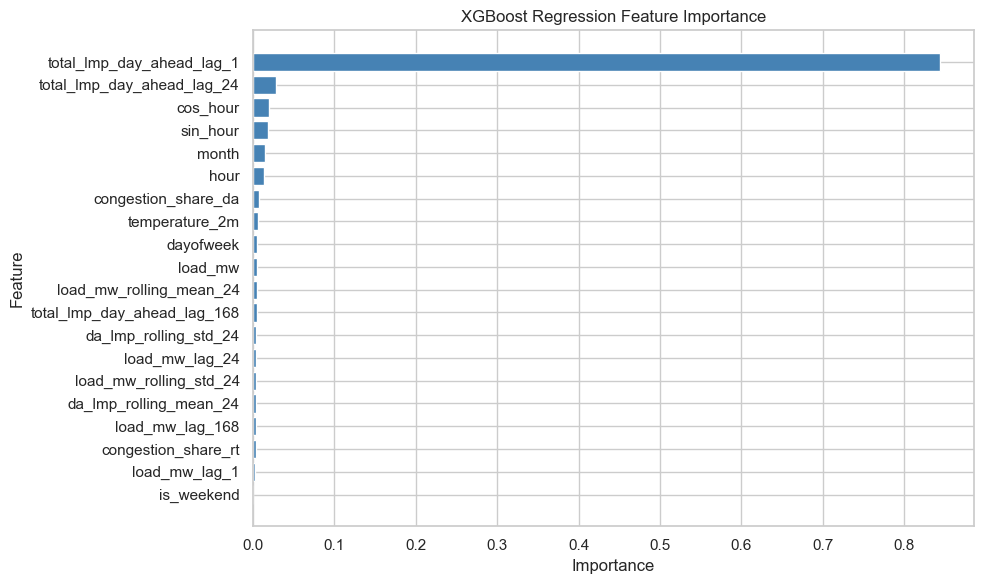

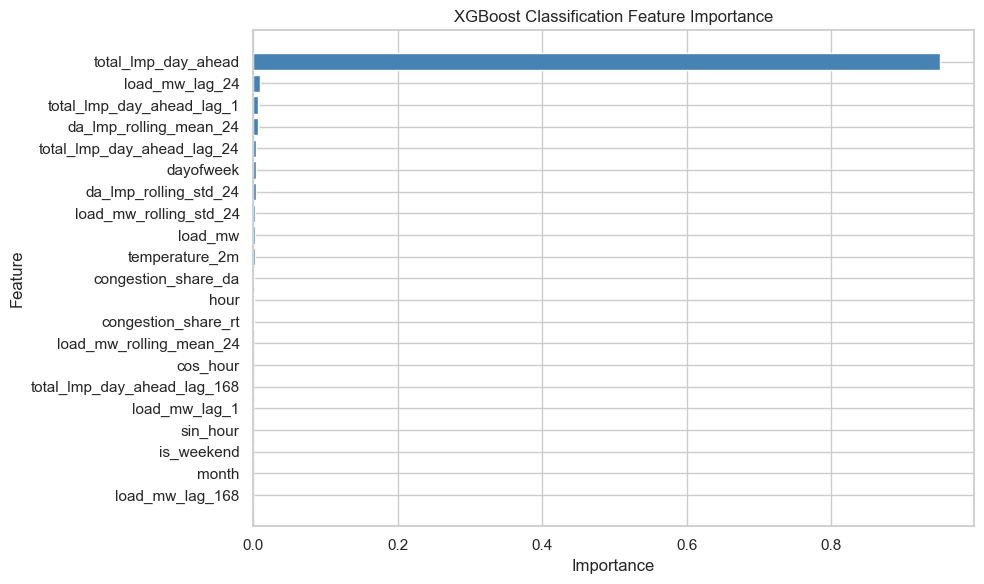

Top XGBoost regression features:
                   feature  importance
 total_lmp_day_ahead_lag_1    0.843579
total_lmp_day_ahead_lag_24    0.028836
                  cos_hour    0.019300
                  sin_hour    0.018058
                     month    0.014844
                      hour    0.013439
       congestion_share_da    0.007220
            temperature_2m    0.006822
                 dayofweek    0.005452
                   load_mw    0.005360
Top XGBoost classification features:
                   feature  importance
       total_lmp_day_ahead    0.949560
            load_mw_lag_24    0.009914
 total_lmp_day_ahead_lag_1    0.007175
    da_lmp_rolling_mean_24    0.006425
total_lmp_day_ahead_lag_24    0.004843
                 dayofweek    0.004644
     da_lmp_rolling_std_24    0.003951
    load_mw_rolling_std_24    0.002838
                   load_mw    0.002672
            temperature_2m    0.002433
shap is not installed in this environment. Install shap to generate SHAP

In [ ]:
def plot_feature_importance(model, feature_names, title):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_feature_importance(reg_model, regression_features, 'XGBoost Regression Feature Importance (Next-Hour DA LMP)')
plot_feature_importance(cls_model, cls_features, 'XGBoost Classification Feature Importance (Next-Hour DA Spike)')

importance_reg = pd.DataFrame({
    'feature': regression_features,
    'importance': reg_model.feature_importances_
}).sort_values('importance', ascending=False)

importance_cls = pd.DataFrame({
    'feature': cls_features,
    'importance': cls_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top XGBoost regression features:')
print(importance_reg.head(10).to_string(index=False))
print('Top XGBoost classification features:')
print(importance_cls.head(10).to_string(index=False))

try:
    import shap
    explainer = shap.TreeExplainer(reg_model)
    shap_values = explainer.shap_values(X_test_reg)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_reg, feature_names=regression_features, plot_type='bar', show=False)
    plt.title('SHAP Summary - XGBoost Regression (Next-Hour DA LMP)')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('shap is not installed in this environment. Install shap to generate SHAP interpretability outputs.')

## Diagnostics

Visualize model performance, next-hour spike prediction behavior, load-LMP relationships, hourly price profiles, and congestion component dynamics. These charts are designed for practical market monitoring and decision support.

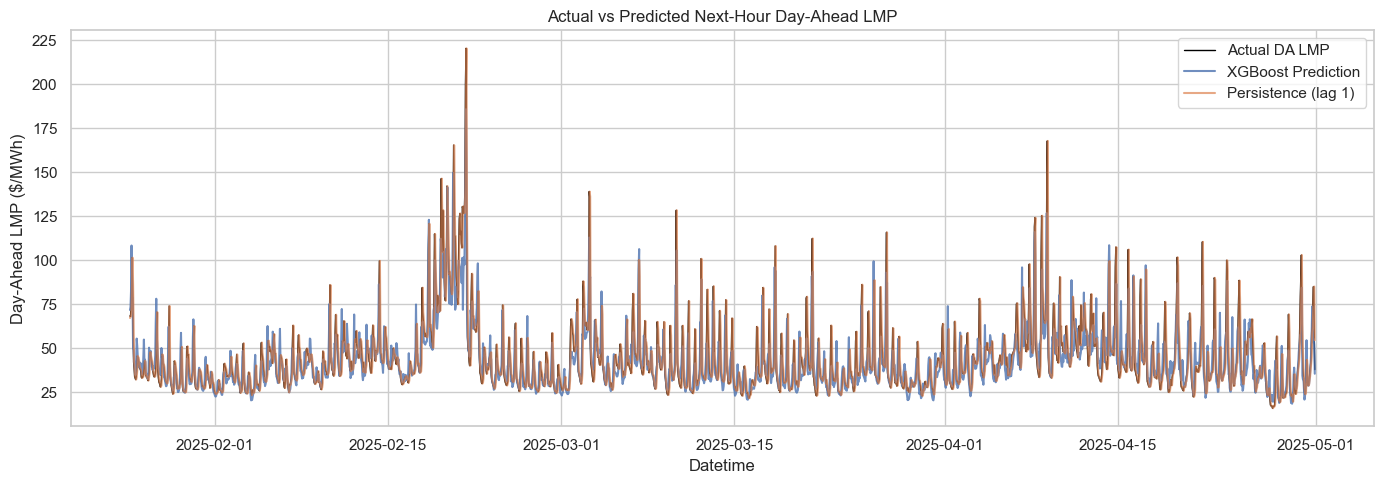

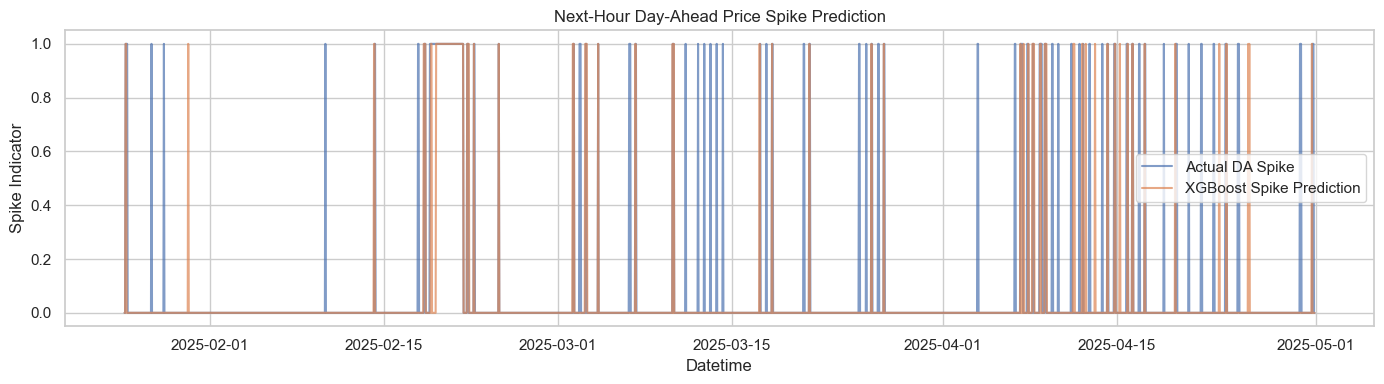

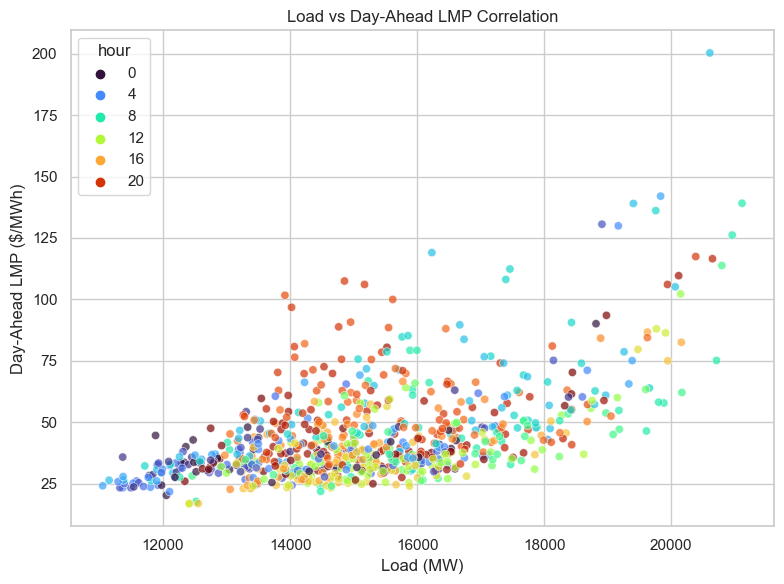

/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


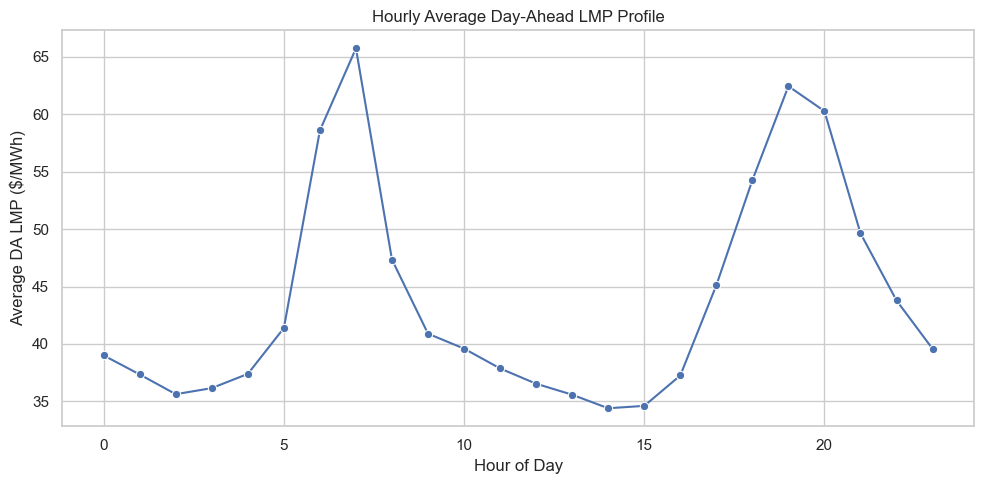

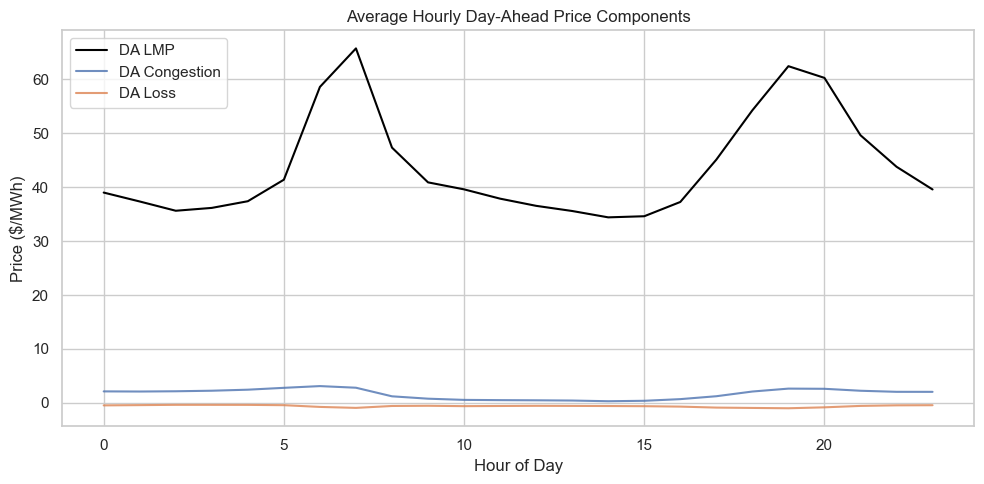

In [86]:
visual_df = test_df[['datetime', 'total_lmp_day_ahead']].copy()
visual_df = visual_df.rename(columns={'total_lmp_day_ahead': 'Actual_DA_LMP'})
visual_df['XGBoost_Prediction'] = y_pred_reg
visual_df['Persistence'] = test_df['total_lmp_day_ahead_lag_1']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(visual_df['datetime'], visual_df['Actual_DA_LMP'], label='Actual DA LMP', color='black', linewidth=1)
ax.plot(visual_df['datetime'], visual_df['XGBoost_Prediction'], label='XGBoost Prediction', alpha=0.8)
ax.plot(visual_df['datetime'], visual_df['Persistence'], label='Persistence (lag 1)', alpha=0.7)
ax.set_title('Actual vs Predicted Next-Hour Day-Ahead LMP')
ax.set_xlabel('Datetime')
ax.set_ylabel('Day-Ahead LMP ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

spike_df = test_df[['datetime', 'da_price_spike']].copy()
spike_df['Prediction'] = y_pred_cls
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spike_df['datetime'], spike_df['da_price_spike'], label='Actual DA Spike', alpha=0.7)
ax.plot(spike_df['datetime'], spike_df['Prediction'], label='XGBoost Spike Prediction', alpha=0.7)
ax.set_title('Next-Hour Day-Ahead Price Spike Prediction')
ax.set_xlabel('Datetime')
ax.set_ylabel('Spike Indicator')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x='load_mw',
    y='total_lmp_day_ahead',
    hue='hour',
    palette='turbo',
    data=test_df.sample(n=min(800, len(test_df)), random_state=42),
    alpha=0.7,
    ax=ax
)
ax.set_title('Load vs Day-Ahead LMP Correlation')
ax.set_xlabel('Load (MW)')
ax.set_ylabel('Day-Ahead LMP ($/MWh)')
plt.tight_layout()
plt.show()

hourly_profile = test_df.groupby('hour')['total_lmp_day_ahead'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly_profile, x='hour', y='total_lmp_day_ahead', marker='o', ax=ax)
ax.set_title('Hourly Average Day-Ahead LMP Profile')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average DA LMP ($/MWh)')
plt.tight_layout()
plt.show()

congestion_profile = test_df.groupby('hour')[['congestion_price_day_ahead', 'marginal_loss_price_day_ahead', 'total_lmp_day_ahead']].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(congestion_profile['hour'], congestion_profile['total_lmp_day_ahead'], label='DA LMP', color='black')
ax.plot(congestion_profile['hour'], congestion_profile['congestion_price_day_ahead'], label='DA Congestion', alpha=0.8)
ax.plot(congestion_profile['hour'], congestion_profile['marginal_loss_price_day_ahead'], label='DA Loss', alpha=0.8)
ax.set_title('Average Hourly Day-Ahead Price Components')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

## Market Interpretation

Summarize the key findings in an analyst-style narrative. This section connects pricing behavior to operational market signals, congestion risk, and potential demand response windows.

The analysis shows that next-hour day-ahead LMP is strongly influenced by both load and congestion components. Peak hourly pricing is concentrated in late afternoon and early evening hours, reflecting traditional demand peaks and higher reserve requirements.

The day-ahead vs real-time spread highlights periods where real-time market adjustments were significant, often coinciding with congestion events and volatility clusters. Monitoring the spread can help trading desks identify hedging opportunities and short-term imbalance risk.

The XGBoost regression model captures the main LMP drivers and confirms that time-of-day seasonality, load momentum, and lagged congestion share are primary inputs to price formation. Feature importance helps signal whether weather/load/congestion or calendar variables are the dominant drivers in the current data window.

For operations, this workflow supports: demand response planning during peak exposure hours, hedge risk assessment for next-hour price spikes, dispatch planning around congestion-prone intervals, and short-term exposure monitoring when spread volatility increases.

This notebook is structured as a utility-scale market analytics workflow: clean data ingestion, market feature engineering, time-series-safe forecasting, and operational interpretation rather than an ad hoc Kaggle exploration.